<a href="https://colab.research.google.com/github/RohitMit77/AML-lab/blob/main/BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load the Breast Cancer Wisconsin dataset
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Dataset path:", path)

df = pd.read_csv(os.path.join(path, "data.csv"))

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Dataset path: /kaggle/input/breast-cancer-wisconsin-data


In [ ]:
# Inspect the dataset structure, columns, missing values, duplicates,and data types
import os
print("Dataset shape:", df.shape)
df.head()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())




Dataset shape: (569, 33)

Missing values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst              

In [ ]:

import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "data.csv"))

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Preprocess the dataset by removing unnecessary columns and encoding the target variable

df = df.drop(columns=["id", "Unnamed: 32"])

df["diagnosis"] = df["diagnosis"].map({
    "M": 0,
    "B": 1
})

print("Dataset shape after processing:", df.shape)
print("\nTarget values:")
print(df["diagnosis"].value_counts())

Dataset shape after processing: (569, 31)

Target values:
diagnosis
1    357
0    212
Name: count, dtype: int64


In [ ]:
# Separate the input features (X) from the target variable (Y)

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [ ]:
# Split the data into 30% training and 70% testing sets while preserving class proportions
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.70,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 170
Testing samples: 399


In [ ]:
# Scale the features and train the Logistic Regression classification model

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
# Evaluate Logistic Regression using accuracy, precision, recall ,F1-score, and confusion matrix

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("===== LOGISTIC REGRESSION =====")

print("Accuracy:", accuracy_score(y_test, logistic_pred))
print("Precision:", precision_score(y_test, logistic_pred))
print("Recall:", recall_score(y_test, logistic_pred))
print("F1 Score:", f1_score(y_test, logistic_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

===== LOGISTIC REGRESSION =====
Accuracy: 0.974937343358396
Precision: 0.96875
Recall: 0.992
F1 Score: 0.9802371541501976

Confusion Matrix:
[[141   8]
 [  2 248]]


In [ ]:
# Train the Decision Tree Classification model and generate test predictions
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


In [ ]:
# Evaluate Decision Tree using accuracy, precision, recall ,F1-score, and confusion matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("===== DECISION TREE =====")

print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1 Score:", f1_score(y_test, tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

===== DECISION TREE =====
Accuracy: 0.9172932330827067
Precision: 0.9288537549407114
Recall: 0.94
F1 Score: 0.9343936381709742

Confusion Matrix:
[[131  18]
 [ 15 235]]


In [ ]:
# Compare Logisitic Regression and Decision Tree using accuracy,precision,recall and F1 score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, tree_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, tree_pred)
    ],
    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, tree_pred)
    ]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression  0.974937   0.968750   0.992  0.980237
1        Decision Tree  0.917293   0.928854   0.940  0.934394


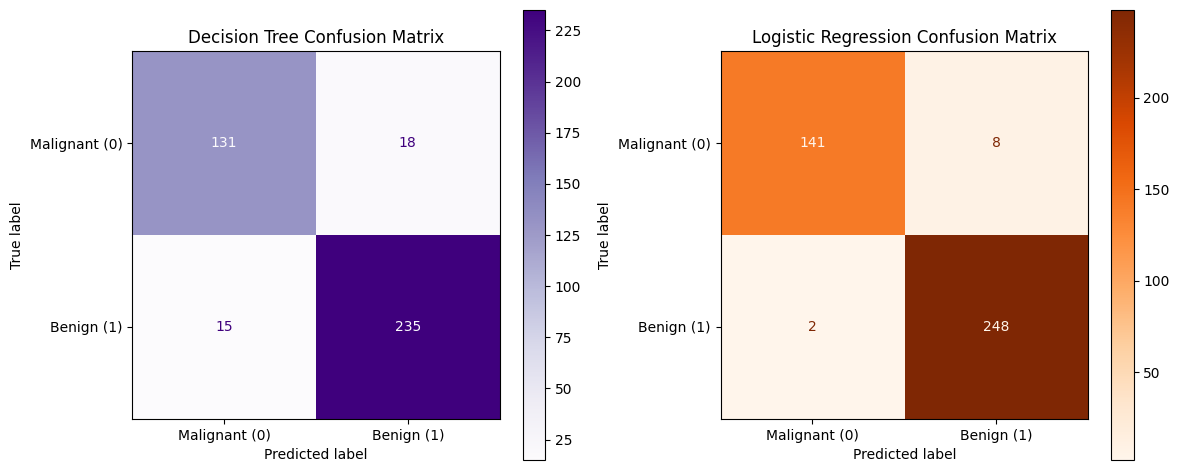

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred,
    display_labels=["Malignant (0)", "Benign (1)"],
    cmap="Purples",
    ax=axes[0]
)

axes[0].set_title("Decision Tree Confusion Matrix")


# Logistic Regression Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    display_labels=["Malignant (0)", "Benign (1)"],
    cmap="Oranges",
    ax=axes[1]
)

axes[1].set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Final Model Comparison Table

results_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Decision Tree": [
        accuracy_score(y_test, tree_pred) * 100,
        precision_score(y_test, tree_pred) * 100,
        recall_score(y_test, tree_pred) * 100,
        f1_score(y_test, tree_pred) * 100
    ],
    "Logistic Regression": [
        accuracy_score(y_test, logistic_pred) * 100,
        precision_score(y_test, logistic_pred) * 100,
        recall_score(y_test, logistic_pred) * 100,
        f1_score(y_test, logistic_pred) * 100
    ]
})

results_table = results_table.round(2)

results_table["Decision Tree"] = results_table["Decision Tree"].astype(str) + "%"
results_table["Logistic Regression"] = results_table["Logistic Regression"].astype(str) + "%"

display(results_table)


,Metric,Decision Tree,Logistic Regression
0,Accuracy,91.73%,97.49%
1,Precision,92.89%,96.88%
2,Recall,94.0%,99.2%
3,F1 Score,93.44%,98.02%


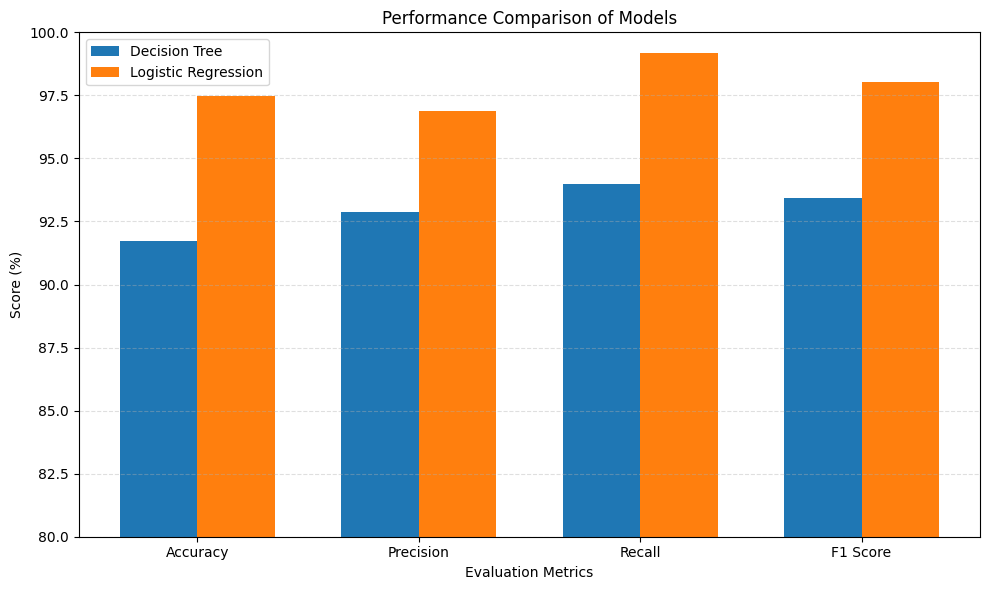

In [ ]:
# Model Comparison Bar Chart

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

decision_tree = [
    accuracy_score(y_test, tree_pred) * 100,
    precision_score(y_test, tree_pred) * 100,
    recall_score(y_test, tree_pred) * 100,
    f1_score(y_test, tree_pred) * 100
]

logistic_regression = [
    accuracy_score(y_test, logistic_pred) * 100,
    precision_score(y_test, logistic_pred) * 100,
    recall_score(y_test, logistic_pred) * 100,
    f1_score(y_test, logistic_pred) * 100
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, decision_tree, width, label="Decision Tree")
plt.bar(x + width/2, logistic_regression, width, label="Logistic Regression")

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score (%)")
plt.title("Performance Comparison of Models")
plt.xticks(x, metrics)
plt.ylim(80, 100)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


### Final Conclusion

Logistic Regression performs better than the Decision Tree across Accuracy,
Precision, Recall, and F1 Score. Therefore, Logistic Regression is the
better-performing model for this breast cancer classification dataset.